In [11]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline

In [12]:
df = pd.read_csv("weather_classification_data.csv")
df.head()

,temperature,humidity,wind_speed,precipitation (%),cloud_cover,atmospheric_pressure,uv_index,season,visibility (km),location,weather_type
0,14,73,9.5,82,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39,96,8.5,71,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30,64,7.0,16,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38,83,1.5,82,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27,74,17.0,66,overcast,990.67,1,Winter,2.5,mountain,Rainy


In [13]:
df.shape

(13200, 11)

In [14]:
df.describe()

,temperature,humidity,wind_speed,precipitation (%),atmospheric_pressure,uv_index,visibility (km)
count,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000
mean,19.127576,68.710833,9.832197,53.644394,1005.827896,4.005758,5.462917
std,17.386327,20.194248,6.908704,31.946541,37.199589,3.856600,3.371499
min,-25.000000,20.000000,0.000000,0.000000,800.120000,0.000000,0.000000
25%,4.000000,57.000000,5.000000,19.000000,994.800000,1.000000,3.000000
50%,21.000000,70.000000,9.000000,58.000000,1007.650000,3.000000,5.000000
75%,31.000000,84.000000,13.500000,82.000000,1016.772500,7.000000,7.500000
max,109.000000,109.000000,48.500000,109.000000,1199.210000,14.000000,20.000000


In [10]:
df.isna().sum()

temperature             0
humidity                0
wind_speed              0
precipitation (%)       0
cloud_cover             0
atmospheric_pressure    0
uv_index                0
season                  0
visibility (km)         0
location                0
weather_type            0
dtype: int64

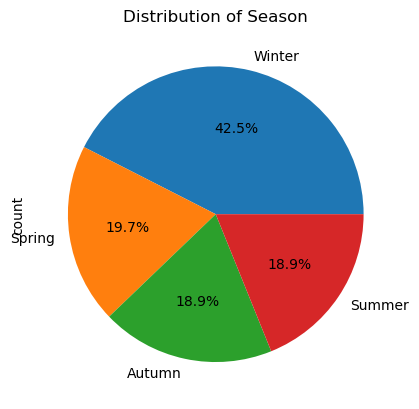

In [17]:
#Step 4: Visualize the distribution of key features

# Visualize season using a pie chart
df['season'].value_counts().plot(kind='pie', autopct='%1.1f%%', title='Distribution of Season')
plt.show()

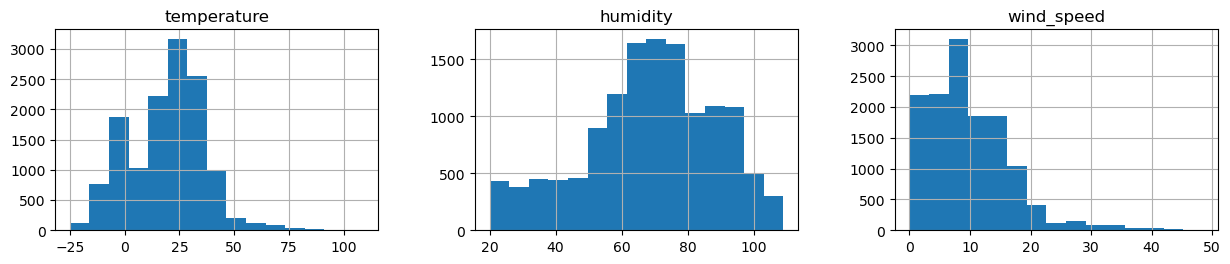

In [18]:
# Visualize temperature, humidity, and wind_speed using histograms

df[['temperature', 'humidity', 'wind_speed']].hist(bins=15, figsize=(15, 6), layout=(2, 3))
plt.show()

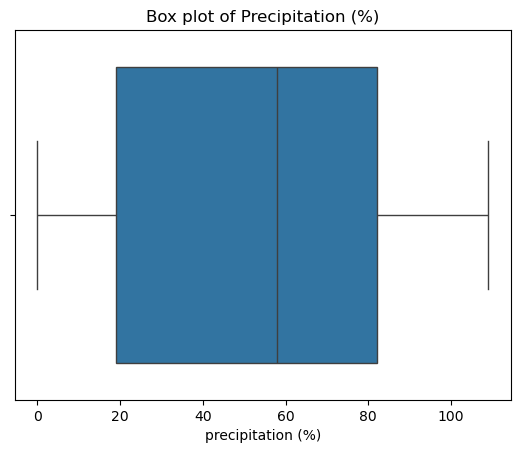

In [19]:
# Visualize precipitation (%) using a box plot
sns.boxplot(x='precipitation (%)', data=df)
plt.title('Box plot of Precipitation (%)')
plt.show()

In [20]:
# Step 1: Encode cloud_cover, location and season using one-hot encoding.

df = pd.get_dummies(df, columns=['cloud_cover', 'location', 'season'], drop_first=True)

In [21]:
# Step 2: Scale the numerical features
scaler = StandardScaler()
numerical_features = ['temperature', 'humidity', 'wind_speed', 'precipitation (%)', 'atmospheric_pressure', 'uv_index', 'visibility (km)']
df[numerical_features] = scaler.fit_transform(df[numerical_features])

In [22]:
# Step3: Display the first few rows of the updated dataset.
df.head()

,temperature,humidity,wind_speed,precipitation (%),atmospheric_pressure,uv_index,visibility (km),weather_type,cloud_cover_cloudy,cloud_cover_overcast,cloud_cover_partly cloudy,location_inland,location_mountain,season_Spring,season_Summer,season_Winter
0,-0.294931,0.212404,-0.048086,0.887629,0.134203,-0.520104,-0.582231,Rainy,False,False,True,True,False,False,False,True
1,1.143035,1.351385,-0.192836,0.543291,0.150602,0.776424,1.345768,Cloudy,False,False,True,True,False,True,False,False
2,0.625367,-0.233285,-0.409962,-1.178401,0.346579,0.257813,0.010999,Sunny,False,False,False,False,True,True,False,False
3,1.085516,0.707613,-1.206089,0.887629,0.549008,0.776424,-1.323769,Sunny,False,False,False,False,False,True,False,False
4,0.452811,0.261924,1.037543,0.386773,-0.407490,-0.779410,-0.878846,Rainy,False,True,False,False,True,False,False,True


In [23]:
# Step 1: Select features and target variable
X = df.drop('weather_type', axis=1)
y = df['weather_type']

# Step 2: Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [24]:
# Step 3: Train SVM with linear kernel
model_linear = SVC(kernel='linear')
model_linear.fit(X_train, y_train)

# Step 4: Print accuracy score
print("Linear Kernel SVM Accuracy on Test Data:", model_linear.score(X_test, y_test))

Linear Kernel SVM Accuracy on Test Data: 0.8845959595959596


In [25]:
# Step 5: Evaluate the model
y_pred_linear = model_linear.predict(X_test)
print("Classification Report for Linear Kernel SVM:")
print(classification_report(y_test, y_pred_linear))

print('*' * 50)

print("Confusion Matrix for Linear Kernel SVM:")
print(confusion_matrix(y_test, y_pred_linear))

Classification Report for Linear Kernel SVM:
              precision    recall  f1-score   support

      Cloudy       0.86      0.84      0.85       955
       Rainy       0.87      0.87      0.87       982
       Snowy       0.88      0.94      0.91      1033
       Sunny       0.92      0.88      0.90       990

    accuracy                           0.88      3960
   macro avg       0.88      0.88      0.88      3960
weighted avg       0.88      0.88      0.88      3960

**************************************************
Confusion Matrix for Linear Kernel SVM:
[[806  82  28  39]
 [ 49 852  67  14]
 [ 26  12 974  21]
 [ 57  29  33 871]]


In [27]:
#Step 1: Train the SVM model with specified hyperparameters
model_custom = SVC(kernel='rbf', C=0.5, gamma='auto', degree=2)
model_custom.fit(X_train, y_train)

# Step 2: Print the model's accuracy score
print("Custom Model Accuracy on Test Data:", model_custom.score(X_test, y_test))

# Step 3: Make predictions on the test set
y_pred_custom = model_custom.predict(X_test)

print('*' * 50)

# Step 4: Evaluate the model using a classification report and confusion matrix
print("Classification Report for Custom SVM Model:")
print(classification_report(y_test, y_pred_custom))

print('*' * 50)

print("Confusion Matrix for Custom SVM Model:")
print(confusion_matrix(y_test, y_pred_custom))

Custom Model Accuracy on Test Data: 0.898989898989899
**************************************************
Classification Report for Custom SVM Model:
              precision    recall  f1-score   support

      Cloudy       0.87      0.87      0.87       955
       Rainy       0.90      0.90      0.90       982
       Snowy       0.90      0.94      0.92      1033
       Sunny       0.93      0.88      0.91       990

    accuracy                           0.90      3960
   macro avg       0.90      0.90      0.90      3960
weighted avg       0.90      0.90      0.90      3960

**************************************************
Confusion Matrix for Custom SVM Model:
[[833  62  36  24]
 [ 50 882  31  19]
 [ 29  10 973  21]
 [ 46  30  42 872]]


In [28]:
# Create a pipeline with two steps: scaling and SVM with RBF kernel
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf'))
])

# Fit the pipeline on the training data
pipeline.fit(X_train, y_train)

# Make predictions using the pipeline on the test data
y_pred_pipeline = pipeline.predict(X_test)

# Print the classification report for the pipeline model
print("Pipeline Classification Report:")
print(classification_report(y_test, y_pred_pipeline))

print('*' * 50)

# Print the confusion matrix for the pipeline model
print("Pipeline Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_pipeline))

Pipeline Classification Report:
              precision    recall  f1-score   support

      Cloudy       0.87      0.88      0.87       955
       Rainy       0.89      0.91      0.90       982
       Snowy       0.92      0.94      0.93      1033
       Sunny       0.93      0.89      0.91       990

    accuracy                           0.90      3960
   macro avg       0.90      0.90      0.90      3960
weighted avg       0.90      0.90      0.90      3960

**************************************************
Pipeline Confusion Matrix:
[[836  64  29  26]
 [ 47 892  22  21]
 [ 30  16 971  16]
 [ 52  27  29 882]]
